# 03 — PriceOracle evaluation on SMARD test window

Compares GridFM / Chronos-2 / Seasonal-naïve forecasts on the 14-day test slice. With no GPU and no `chronos-forecasting`/`gridfm` packages installed, both fall through to the naïve baseline — the `source` label on each PriceForecast reports which code path produced the numbers.

loaded 9,312 rows spanning 2026-01-12 00:00:00+00:00 .. 2026-04-18 23:45:00+00:00


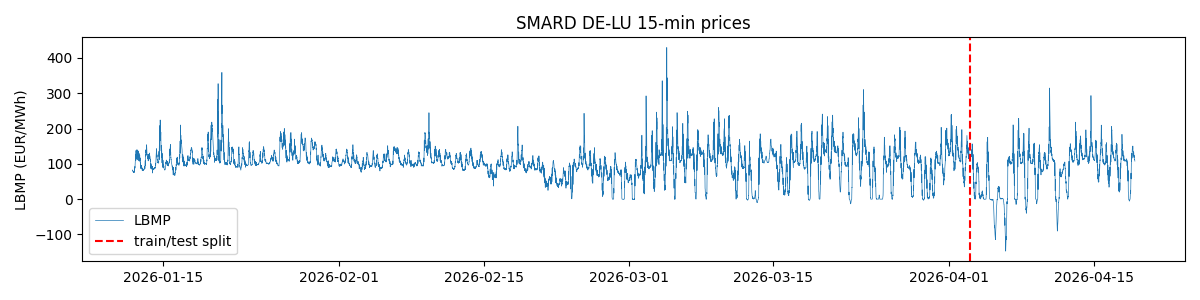

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython import get_ipython
from aerogrid.price_oracle import load_price_history, make_oracle
from aerogrid.config import SMARD_TEST_START, SMARD_TEST_END

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

prices = load_price_history()
print(f"loaded {len(prices):,} rows spanning {prices['timestamp'].min()} .. {prices['timestamp'].max()}")

# Train/test shapes
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(prices["timestamp"], prices["lbmp"], lw=0.5, label="LBMP")
ax.axvline(SMARD_TEST_START, color="red", ls="--", label="train/test split")
ax.set_ylabel("LBMP (EUR/MWh)"); ax.legend(); ax.set_title("SMARD DE-LU 15-min prices")
plt.tight_layout(); plt.show()

GridFMPriceOracle: gridfm or torch not installed — will cascade to Chronos fallback
ChronosPriceOracle: torch or chronos not available — will use SeasonalNaive fallback
ChronosPriceOracle: torch or chronos not available — will use SeasonalNaive fallback


    gridfm  sources=gridfm/fallback_chronos/fallback_naive   MAE=43.84  RMSE=58.41  MAPE_strict=10168.3%  MAPE_floor1=762.0%
   chronos  sources=chronos/fallback_naive                   MAE=43.84  RMSE=58.41  MAPE_strict=10168.3%  MAPE_floor1=762.0%


GridFMPriceOracle: gridfm or torch not installed — will cascade to Chronos fallback
ChronosPriceOracle: torch or chronos not available — will use SeasonalNaive fallback


     naive  sources=naive                                    MAE=43.84  RMSE=58.41  MAPE_strict=10168.3%  MAPE_floor1=762.0%


ChronosPriceOracle: torch or chronos not available — will use SeasonalNaive fallback


day0     gridfm  source=gridfm/fallback_chronos/fallback_naive MAE=49.73  RMSE=59.73  MAPE_strict=2208.6%  MAPE_floor1=605.9%
day0    chronos  source=chronos/fallback_naive         MAE=49.73  RMSE=59.73  MAPE_strict=2208.6%  MAPE_floor1=605.9%
day0      naive  source=naive                          MAE=49.73  RMSE=59.73  MAPE_strict=2208.6%  MAPE_floor1=605.9%


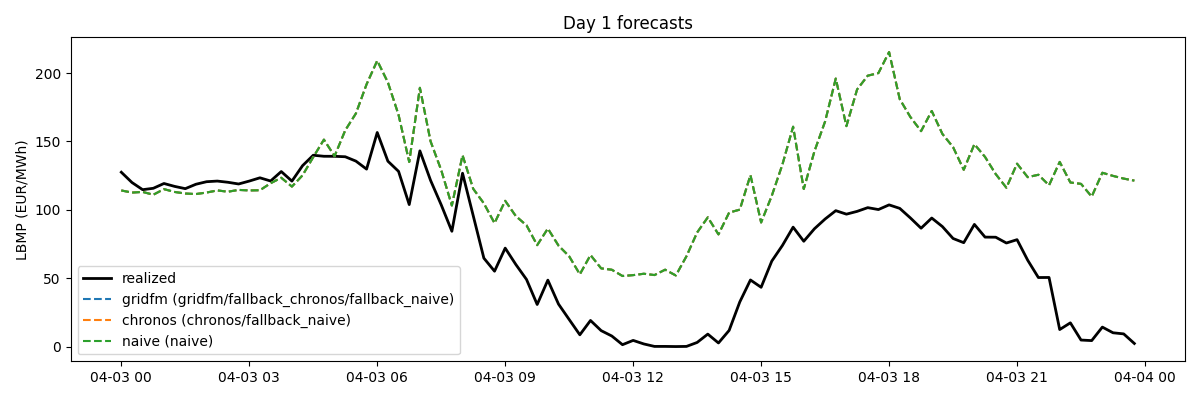

In [2]:
# Rolling 24-h forecasts on each day of the test window.
from datetime import timedelta
realized = prices[(prices["timestamp"] >= SMARD_TEST_START) & (prices["timestamp"] < SMARD_TEST_END)]
actual = realized["lbmp"].to_numpy()
impls = ["gridfm", "chronos", "naive"]
errors = {}
for impl in impls:
    oracle = make_oracle(impl)
    preds = []
    sources = []
    for day in pd.date_range(SMARD_TEST_START, SMARD_TEST_END - timedelta(days=1), freq="1D"):
        fc = oracle.get_15min_forecast(day, prices)
        preds.extend(fc.median)
        sources.append(fc.source)
    preds = np.array(preds[: len(realized)])
    abs_err = np.abs(preds - actual)
    mae = abs_err.mean()
    rmse = np.sqrt(np.mean((preds - actual) ** 2))
    nonzero_actual = np.abs(actual) > 0
    mape_strict = (
        (abs_err[nonzero_actual] / np.abs(actual[nonzero_actual])).mean() * 100
        if nonzero_actual.any()
        else np.nan
    )
    mape_floor1 = (abs_err / np.maximum(np.abs(actual), 1.0)).mean() * 100
    errors[impl] = {
        "mae": mae,
        "rmse": rmse,
        "mape_strict": mape_strict,
        "mape_floor1": mape_floor1,
        "source": sorted(set(sources)),
    }
    print(
        f"{impl:>10s}  sources={','.join(sorted(set(sources))):<40s} "
        f"MAE={mae:.2f}  RMSE={rmse:.2f}  "
        f"MAPE_strict={mape_strict:.1f}%  MAPE_floor1={mape_floor1:.1f}%"
    )

# One-day closeup
day0 = SMARD_TEST_START
slice_real = realized[(realized["timestamp"] >= day0) & (realized["timestamp"] < day0 + timedelta(days=1))]
actual_day0 = slice_real["lbmp"].to_numpy()
one_day_errors = {}

plt.figure(figsize=(12,4))
plt.plot(slice_real["timestamp"], slice_real["lbmp"], "k-", label="realized", lw=2)
for impl in impls:
    fc = make_oracle(impl).get_15min_forecast(day0, prices)
    t = pd.date_range(fc.slot_start, periods=len(fc.median), freq="15min", tz="UTC")
    pred_day0 = np.array(fc.median[: len(actual_day0)])
    abs_err_day0 = np.abs(pred_day0 - actual_day0)
    mae_day0 = abs_err_day0.mean()
    rmse_day0 = np.sqrt(np.mean((pred_day0 - actual_day0) ** 2))
    nonzero_actual_day0 = np.abs(actual_day0) > 0
    mape_strict_day0 = (
        (abs_err_day0[nonzero_actual_day0] / np.abs(actual_day0[nonzero_actual_day0])).mean() * 100
        if nonzero_actual_day0.any()
        else np.nan
    )
    mape_floor1_day0 = (abs_err_day0 / np.maximum(np.abs(actual_day0), 1.0)).mean() * 100
    one_day_errors[impl] = {
        "source": fc.source,
        "mae": mae_day0,
        "rmse": rmse_day0,
        "mape_strict": mape_strict_day0,
        "mape_floor1": mape_floor1_day0,
    }
    print(
        f"day0 {impl:>10s}  source={fc.source:<30s} "
        f"MAE={mae_day0:.2f}  RMSE={rmse_day0:.2f}  "
        f"MAPE_strict={mape_strict_day0:.1f}%  MAPE_floor1={mape_floor1_day0:.1f}%"
    )
    plt.plot(t, fc.median, ls="--", label=f"{impl} ({fc.source})")
plt.ylabel("LBMP (EUR/MWh)"); plt.legend(); plt.title(f"Day 1 forecasts"); plt.tight_layout(); plt.show()